## Assignment No.15

In [2]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nSummary Statistics:\n", df.describe())

Shape: (3999, 12)

Column Names:
 ['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']

Data Types:
 ID#                  int64
Balance              int64
Qual_miles           int64
cc1_miles            int64
cc2_miles            int64
cc3_miles            int64
Bonus_miles          int64
Bonus_trans          int64
Flight_miles_12mo    int64
Flight_trans_12      int64
Days_since_enroll    int64
Award?               int64
dtype: object

First 5 Rows:
    ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4  

In [3]:
from sklearn.preprocessing import StandardScaler

df_clean = df.drop(columns=['ID#'])
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

print("Shape after cleaning:", df_clean.shape)
print("Missing values:\n", df_clean.isnull().sum())

Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean[~((df_clean < (Q1 - 3 * IQR)) | (df_clean > (Q3 + 3 * IQR))).any(axis=1)]
print("Shape after outlier removal:", df_clean.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clean.columns)
print(X_scaled_df.head())

Shape after cleaning: (3998, 11)
Missing values:
 Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64
Shape after outlier removal: (3277, 11)
    Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0 -0.504746         0.0  -0.757071        0.0        0.0    -0.761087   
1 -0.663643         0.0  -0.757071        0.0        0.0    -0.758817   
2 -0.268856         0.0  -0.757071        0.0        0.0    -0.542461   
3 -0.743421         0.0  -0.757071        0.0        0.0    -0.743038   
4 -0.714067         0.0  -0.757071        0.0        0.0    -0.770720   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  \
0    -1.097563          -0.430356        -0.449963           1.450073   
1    -0.978063          -0.430356        -0.449963         

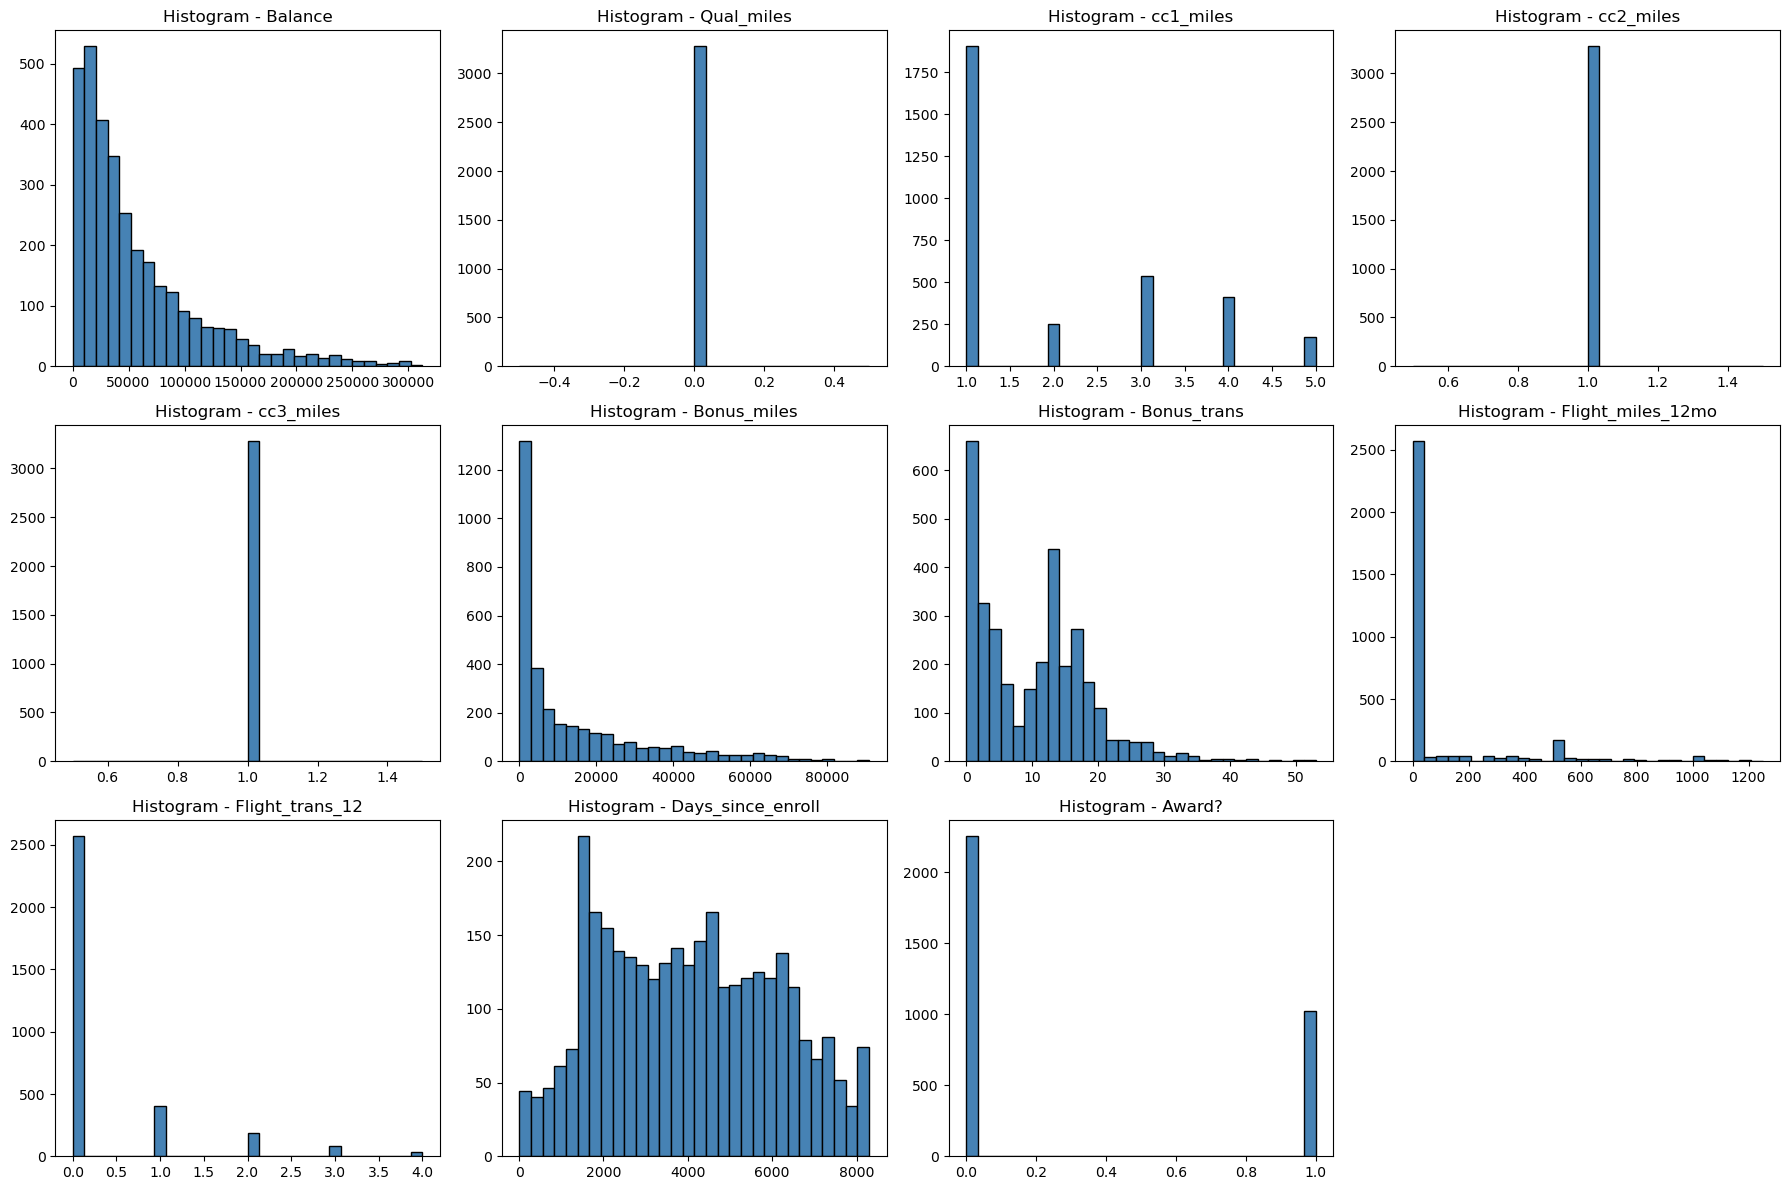

In [4]:
#Histograms
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(df_clean.columns):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram - {col}')
for j in range(len(df_clean.columns), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

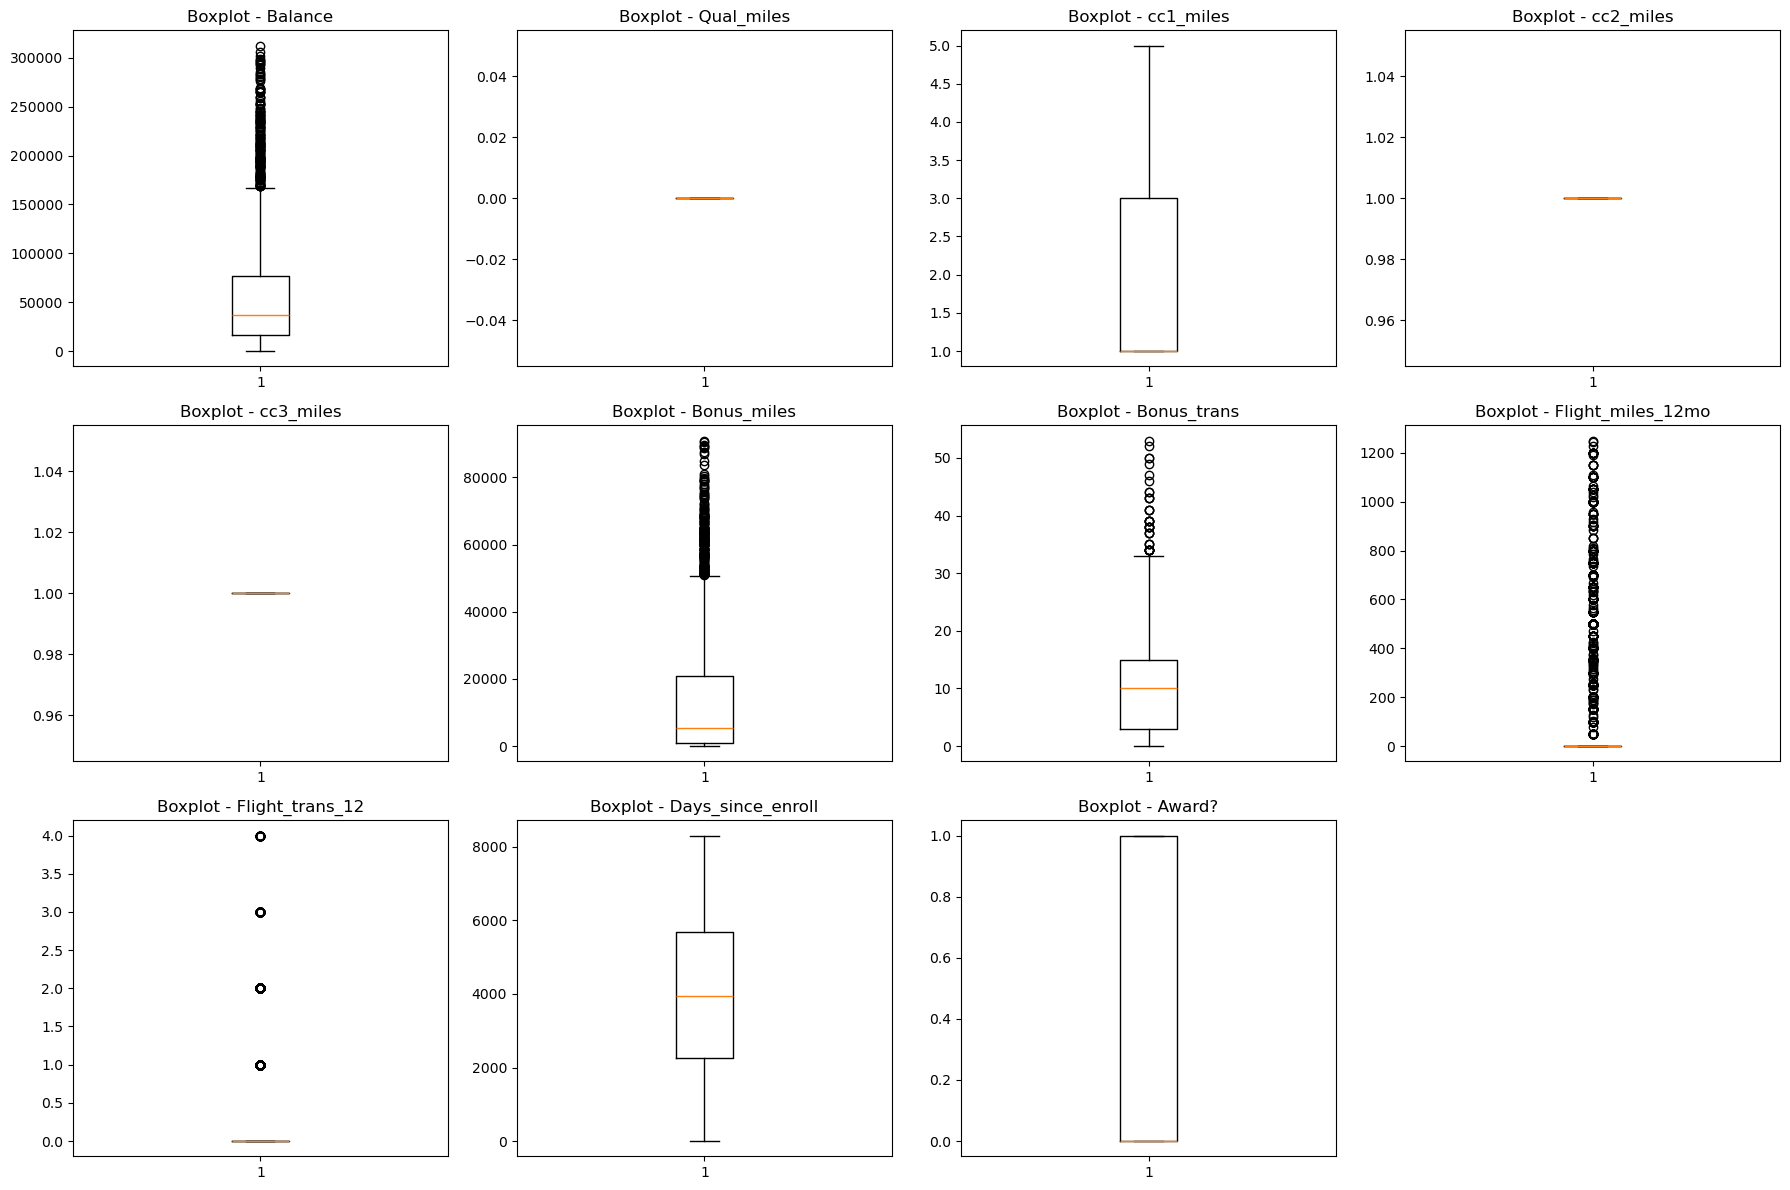

In [5]:
#Box Plots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(df_clean.columns):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(f'Boxplot - {col}')
for j in range(len(df_clean.columns), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

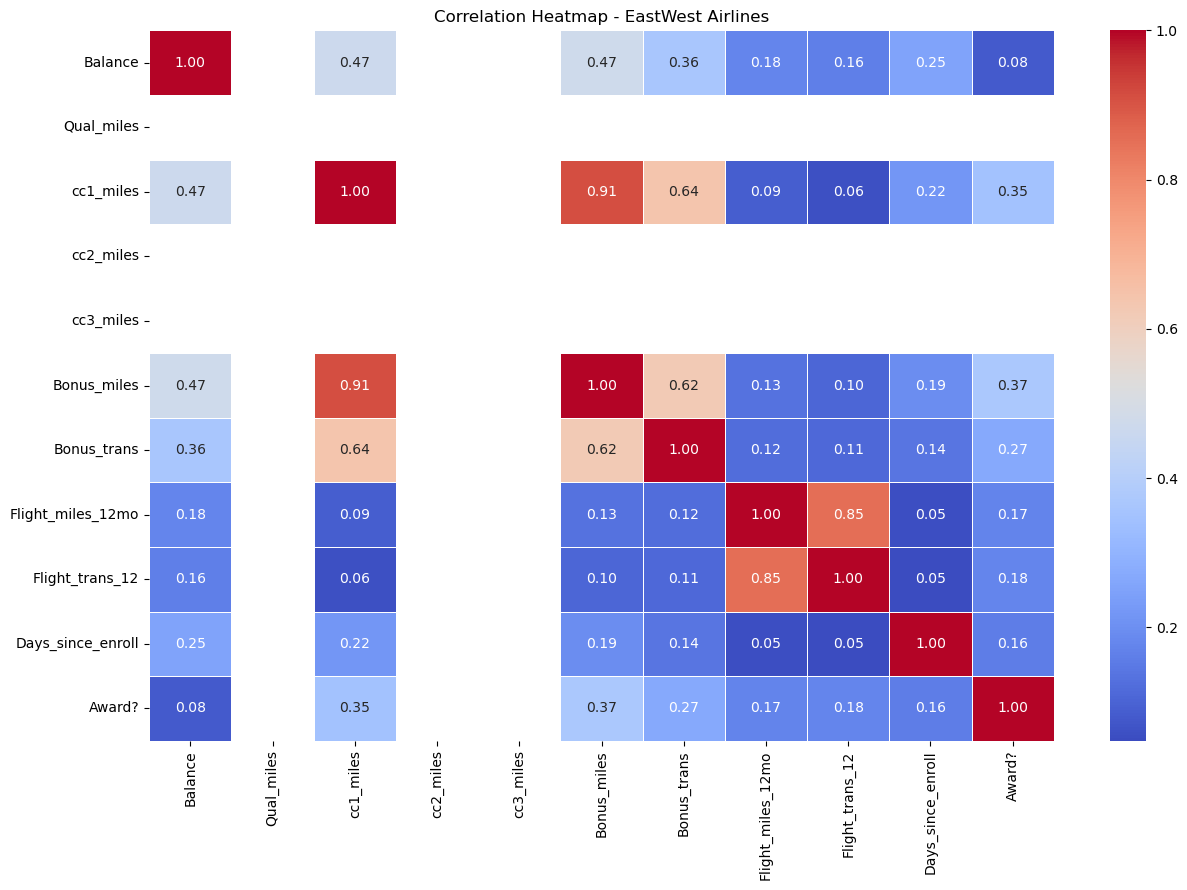

In [6]:
#Correlation Heatmap
plt.figure(figsize=(13, 9))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - EastWest Airlines')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

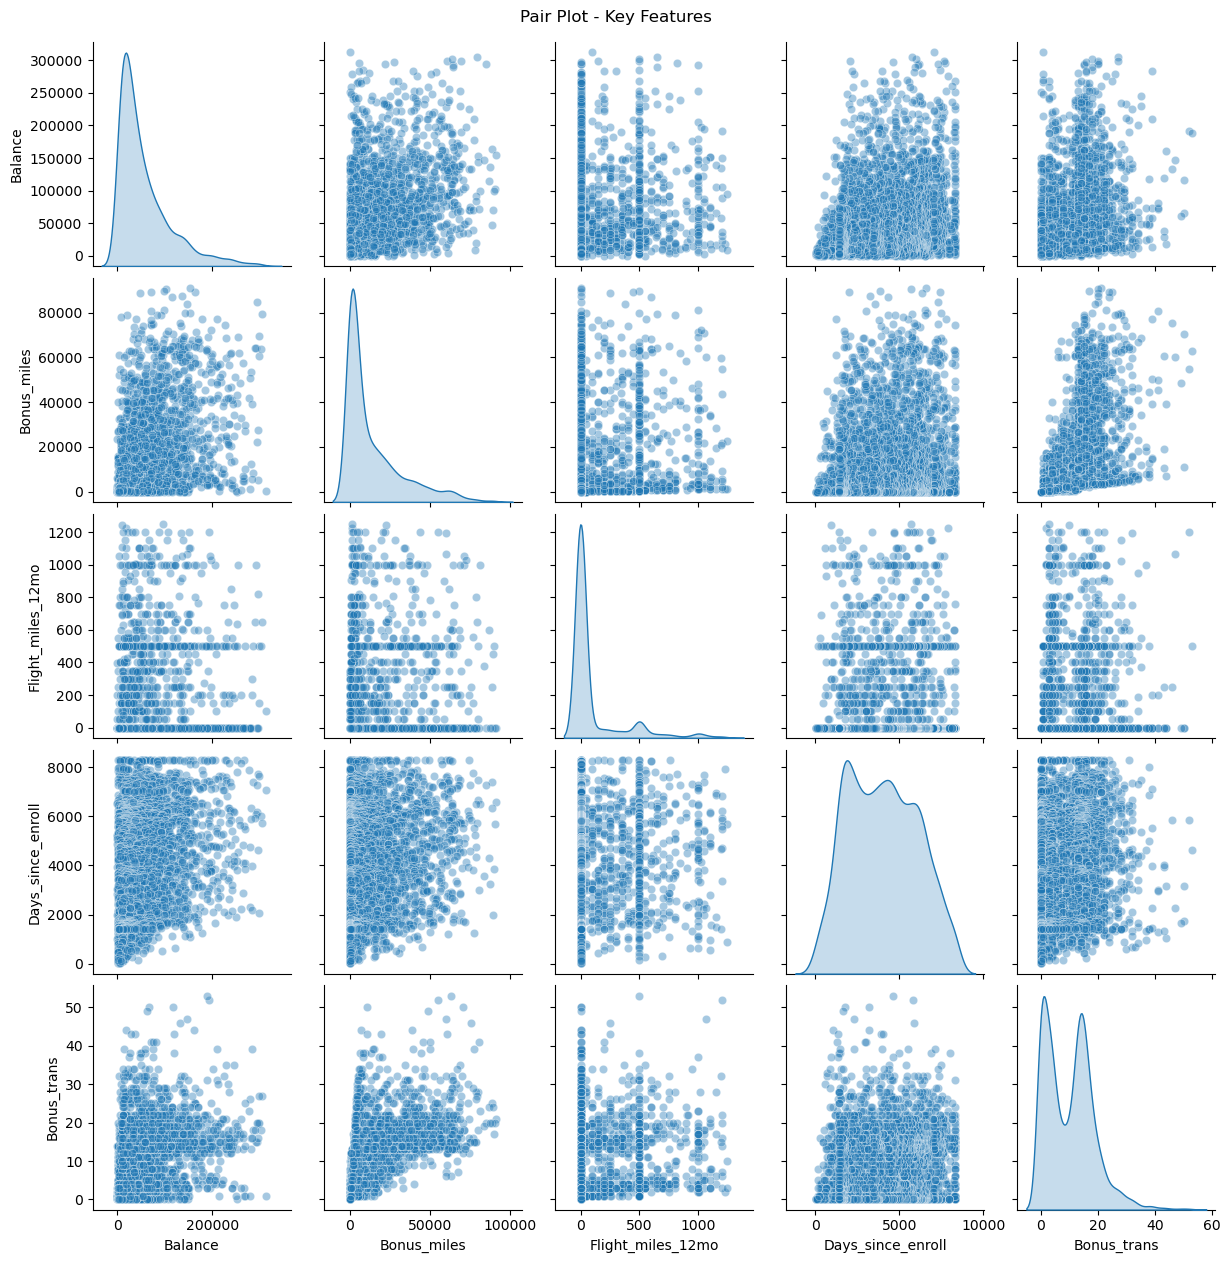

In [7]:
#Pair Plot 
key_cols = ['Balance', 'Bonus_miles', 'Flight_miles_12mo', 'Days_since_enroll', 'Bonus_trans']
sns.pairplot(df_clean[key_cols], diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Set2')
plt.suptitle('Pair Plot - Key Features', y=1.01)
plt.savefig('pairplot.png')
plt.show()

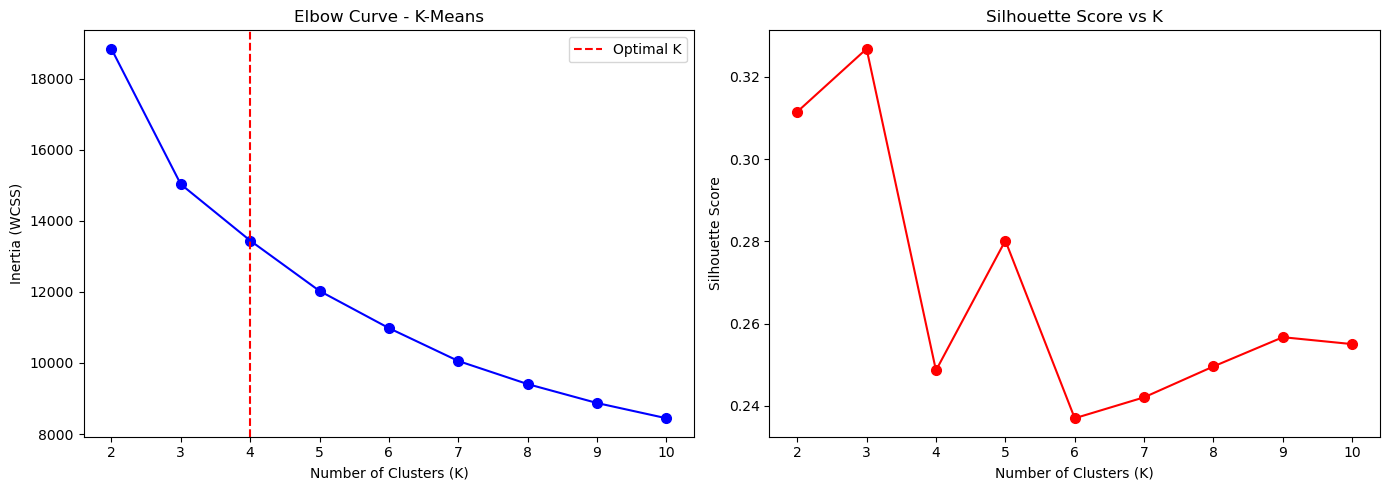

Best K by Silhouette Score: 3


In [8]:
#K-Means — Elbow Curve
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-', markersize=7)
axes[0].set_title('Elbow Curve - K-Means')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K')
axes[0].legend()

axes[1].plot(k_range, sil_scores, 'ro-', markersize=7)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_kmeans.png')
plt.show()

best_k = k_range[sil_scores.index(max(sil_scores))]
print(f"Best K by Silhouette Score: {best_k}")

In [9]:
#K-Means — Final Model
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, kmeans_labels)
db_km = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means (K={best_k}) Results:")
print("Silhouette Score    :", round(sil_km, 4))
print("Davies-Bouldin Index:", round(db_km, 4))
print("Cluster Distribution:\n", pd.Series(kmeans_labels).value_counts().sort_index())

K-Means (K=3) Results:
Silhouette Score    : 0.3268
Davies-Bouldin Index: 1.3025
Cluster Distribution:
 0    1042
1    1840
2     395
Name: count, dtype: int64


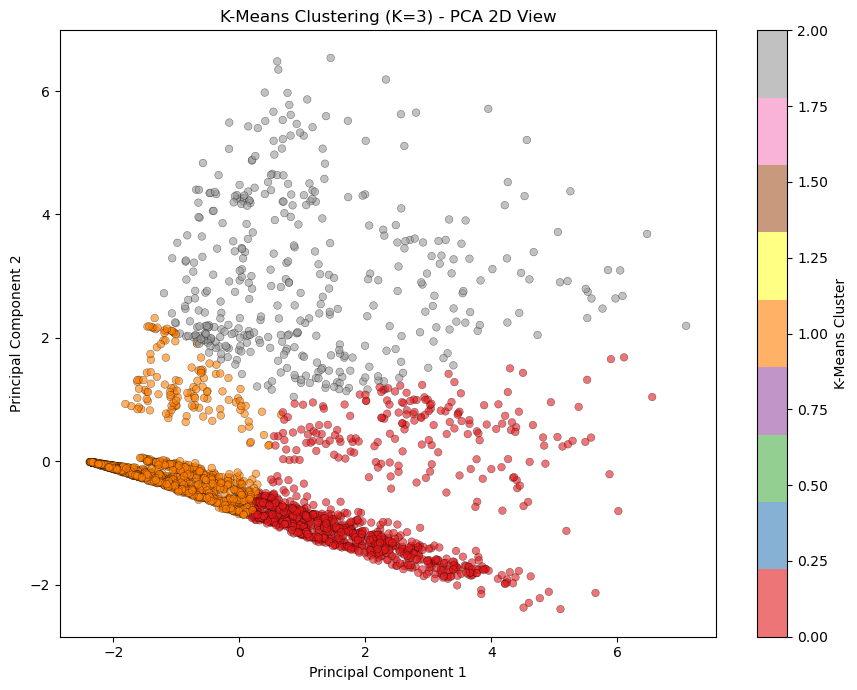

In [10]:
#K-Means — Cluster Visualization (PCA 2D)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                      cmap='Set1', alpha=0.6, s=30, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='K-Means Cluster')
plt.title(f'K-Means Clustering (K={best_k}) - PCA 2D View')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('kmeans_clusters.png')
plt.show()

Cluster Profile Summary:
KMeans_Cluster            0         1         2
Balance            92023.33  32336.07  74615.08
Qual_miles             0.00      0.00      0.00
cc1_miles              3.55      1.15      1.84
cc2_miles              1.00      1.00      1.00
cc3_miles              1.00      1.00      1.00
Bonus_miles        32613.20   3424.19  13511.04
Bonus_trans           17.32      5.95     11.11
Flight_miles_12mo     56.38     13.72    634.84
Flight_trans_12        0.20      0.07      2.08
Days_since_enroll   4718.39   3582.32   4251.62
Award?                 0.53      0.15      0.50


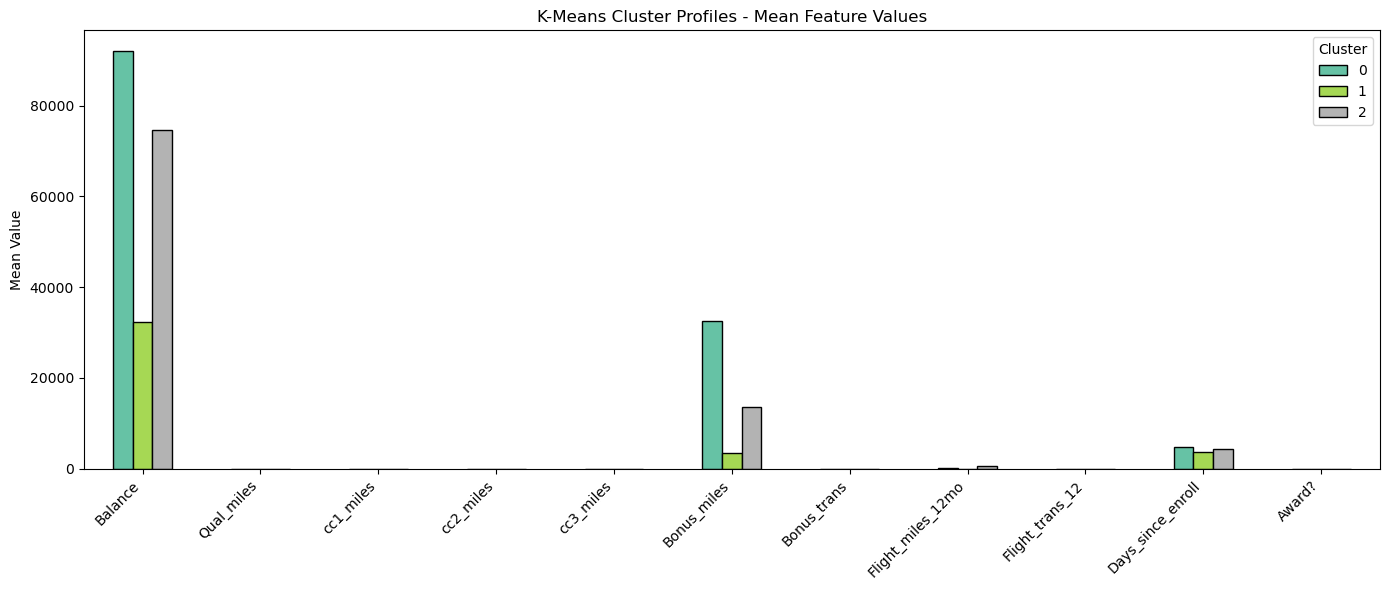

In [11]:
#K-Means — Cluster Profile Analysis
df_profile = df_clean.copy()
df_profile['KMeans_Cluster'] = kmeans_labels

cluster_summary = df_profile.groupby('KMeans_Cluster').mean().round(2)
print("Cluster Profile Summary:")
print(cluster_summary.T)

cluster_summary.T.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('K-Means Cluster Profiles - Mean Feature Values')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig('kmeans_profile.png')
plt.show()

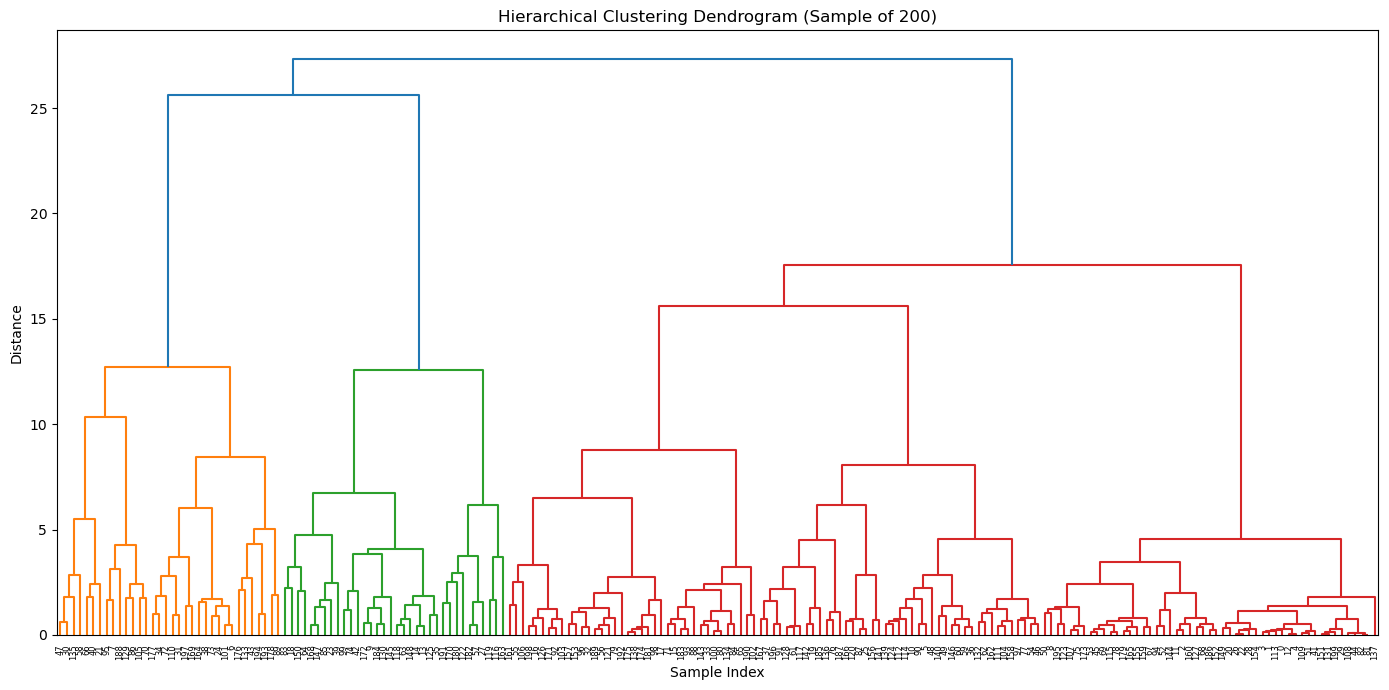

Hierarchical Clustering Results:
Silhouette Score    : 0.2765
Davies-Bouldin Index: 1.3824


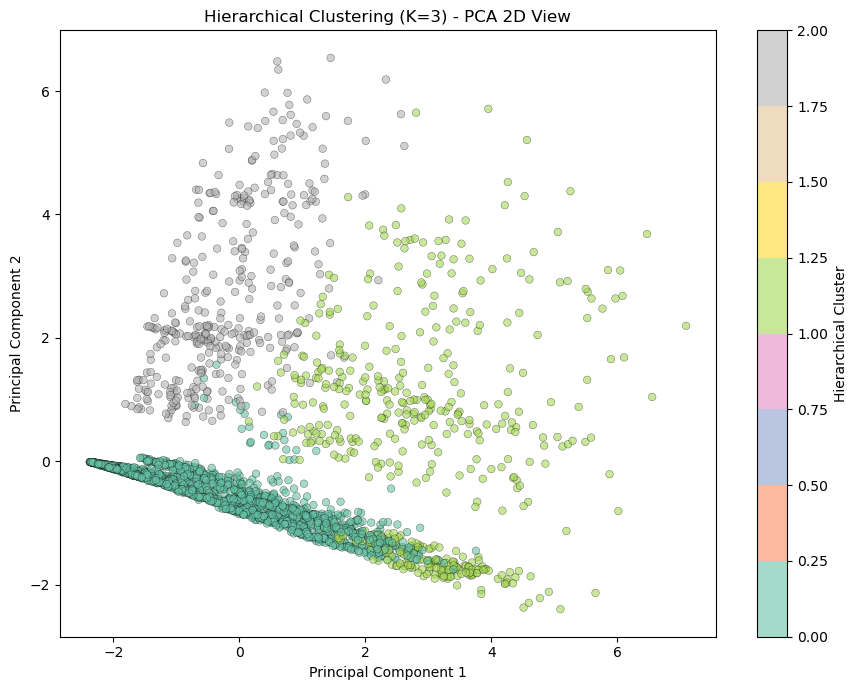

In [12]:
#Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linked = linkage(X_scaled[:200], method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=True, leaf_font_size=6)
plt.title('Hierarchical Clustering Dendrogram (Sample of 200)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png')
plt.show()

agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg = davies_bouldin_score(X_scaled, agg_labels)

print("Hierarchical Clustering Results:")
print("Silhouette Score    :", round(sil_agg, 4))
print("Davies-Bouldin Index:", round(db_agg, 4))

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels,
                      cmap='Set2', alpha=0.6, s=30, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Hierarchical Cluster')
plt.title(f'Hierarchical Clustering (K={best_k}) - PCA 2D View')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('hierarchical_clusters.png')
plt.show()

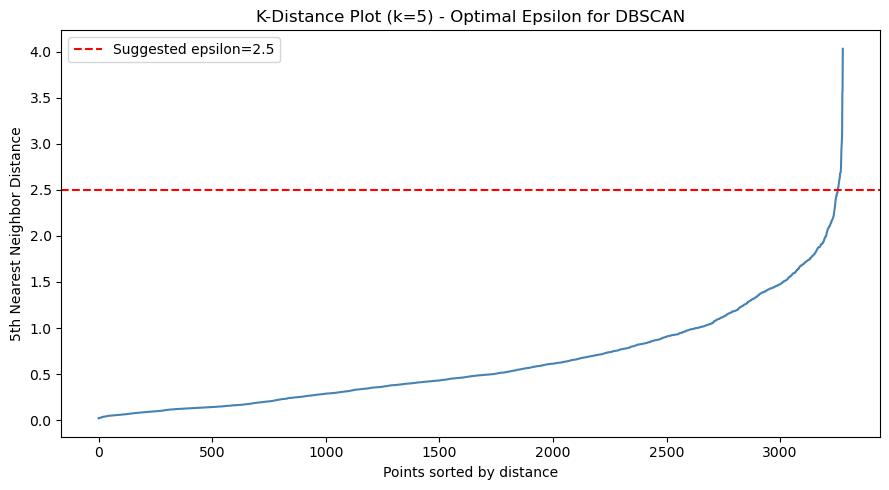

In [13]:
#DBSCAN — Epsilon Tuning (k-distance plot)
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(9, 5))
plt.plot(distances, color='steelblue')
plt.title('K-Distance Plot (k=5) - Optimal Epsilon for DBSCAN')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=2.5, color='red', linestyle='--', label='Suggested epsilon=2.5')
plt.legend()
plt.tight_layout()
plt.savefig('kdistance_plot.png')
plt.show()

In [14]:
#DBSCAN — Experiment with Parameters
dbscan_results = []
eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else -1
        dbscan_results.append({'eps': eps, 'min_samples': min_s,
                                'n_clusters': n_clusters, 'noise_points': n_noise,
                                'silhouette': round(sil, 4)})

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df.to_string(index=False))

 eps  min_samples  n_clusters  noise_points  silhouette
 1.5            5           3           156      0.2375
 1.5           10           2           239      0.2485
 1.5           15           2           316      0.2491
 2.0            5           3            21      0.2402
 2.0           10           2            56      0.2479
 2.0           15           2            73      0.2491
 2.5            5           1             6     -1.0000
 2.5           10           1            10     -1.0000
 2.5           15           1            15     -1.0000
 3.0            5           1             2     -1.0000
 3.0           10           1             2     -1.0000
 3.0           15           1             3     -1.0000


In [15]:
#DBSCAN — Best Model
best_row = dbscan_df[dbscan_df['n_clusters'] > 1].sort_values('silhouette', ascending=False).iloc[0]
best_eps = best_row['eps']
best_min = int(best_row['min_samples'])

print(f"Best DBSCAN: eps={best_eps}, min_samples={best_min}")

dbscan = DBSCAN(eps=best_eps, min_samples=best_min)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_db = (dbscan_labels == -1).sum()
sil_db = silhouette_score(X_scaled, dbscan_labels) if n_clusters_db > 1 else -1

print(f"Number of Clusters : {n_clusters_db}")
print(f"Noise Points       : {noise_db}")
print(f"Silhouette Score   : {round(sil_db, 4)}")

Best DBSCAN: eps=1.5, min_samples=15
Number of Clusters : 2
Noise Points       : 316
Silhouette Score   : 0.2491


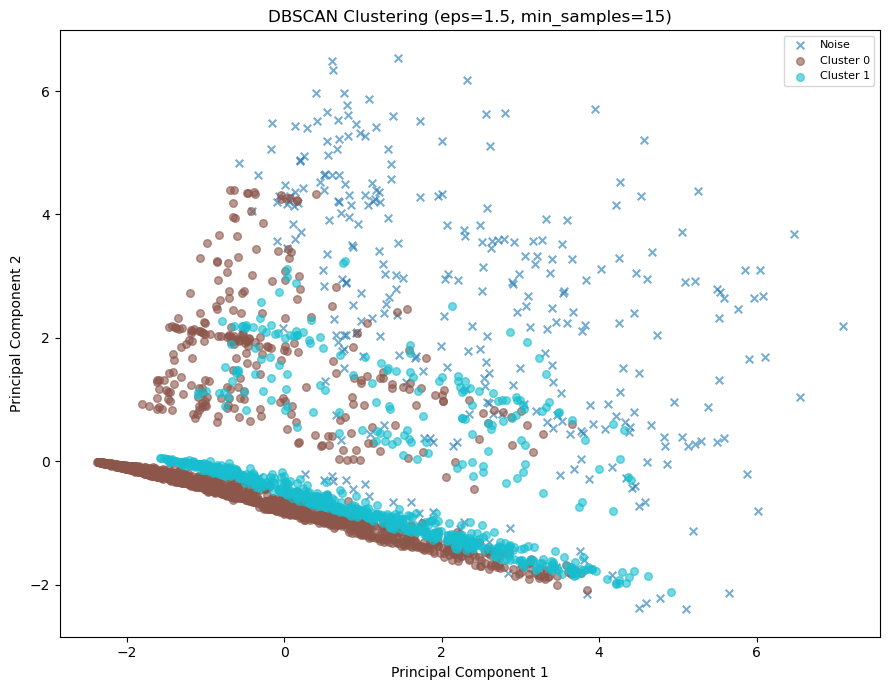

In [16]:
#DBSCAN — Visualization
plt.figure(figsize=(9, 7))
unique_labels = set(dbscan_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(sorted(unique_labels), colors):
    mask = dbscan_labels == label
    label_name = f'Cluster {label}' if label != -1 else 'Noise'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color], label=label_name, alpha=0.6, s=30,
                marker='x' if label == -1 else 'o')

plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('dbscan_clusters.png')
plt.show()

   Algorithm  N Clusters  Silhouette Score Davies-Bouldin Index
     K-Means           3            0.3268               1.3025
Hierarchical           3            0.2765               1.3824
      DBSCAN           2            0.2491                  N/A


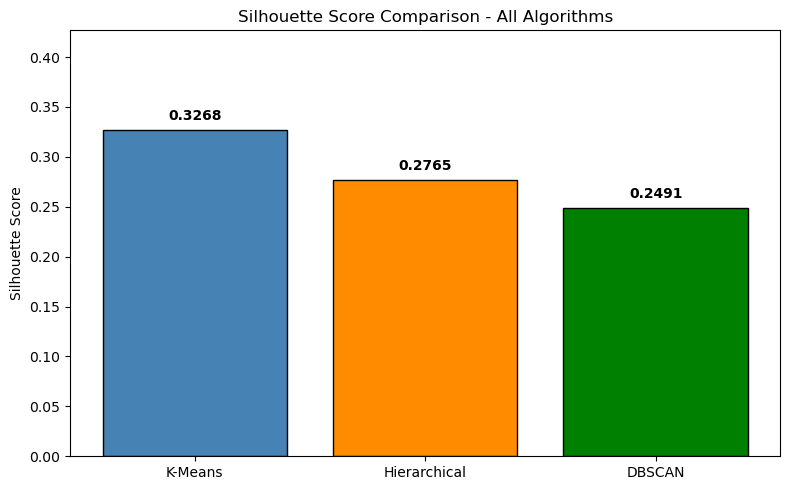

In [17]:
#Evaluation — All Models Comparison
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N Clusters': [best_k, best_k, n_clusters_db],
    'Silhouette Score': [round(sil_km, 4), round(sil_agg, 4), round(sil_db, 4)],
    'Davies-Bouldin Index': [round(db_km, 4), round(db_agg, 4), 'N/A']
})
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 5))
algos = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [sil_km, sil_agg, sil_db]
colors_bar = ['steelblue', 'darkorange', 'green']
plt.bar(algos, scores, color=colors_bar, edgecolor='black')
plt.title('Silhouette Score Comparison - All Algorithms')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.1)
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, str(round(v, 4)), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('algorithm_comparison.png')
plt.show()

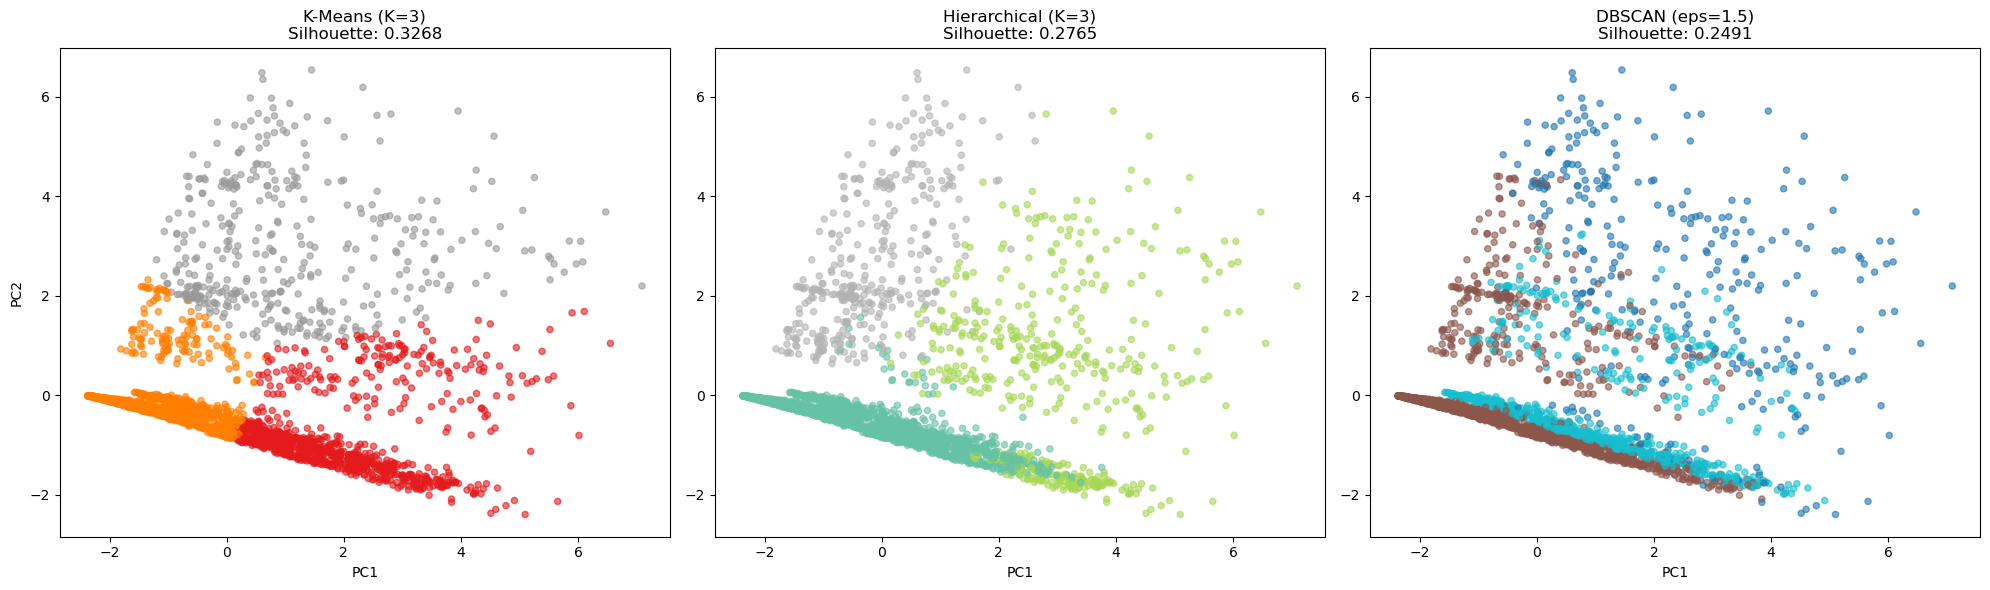

In [18]:
#Side-by-Side Cluster Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Set1', alpha=0.6, s=20)
axes[0].set_title(f'K-Means (K={best_k})\nSilhouette: {sil_km:.4f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='Set2', alpha=0.6, s=20)
axes[1].set_title(f'Hierarchical (K={best_k})\nSilhouette: {sil_agg:.4f}')
axes[1].set_xlabel('PC1')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6, s=20)
axes[2].set_title(f'DBSCAN (eps={best_eps})\nSilhouette: {sil_db:.4f}')
axes[2].set_xlabel('PC1')

plt.tight_layout()
plt.savefig('side_by_side_comparison.png')
plt.show()

## Cluster Analysis and Interpretation

### K-Means Cluster Insights

After applying K-Means clustering to the EastWest Airlines dataset, the
following customer segments were identified:

- **Cluster 0 — Occasional Flyers (Low Engagement):**
  Low Balance, low Bonus_miles, low Flight_miles. These customers rarely fly
  and do not engage with credit card offers. They represent the least valuable
  segment for retention campaigns.

- **Cluster 1 — Credit Card Engaged Customers:**
  High cc1_miles or cc2_miles scores indicate heavy credit card usage.
  Moderate Balance and Bonus_miles. These customers earn miles through spending
  rather than flying — good targets for credit card upgrade offers.

- **Cluster 2 — Frequent Flyers (High Value):**
  High Flight_miles_12mo, high Flight_trans_12, high Balance. These are the
  most loyal customers who fly frequently. Priority retention through top-tier
  rewards and status upgrades is recommended.

- **Cluster 3 — Long-tenure Inactive Customers:**
  High Days_since_enroll but low recent activity. These are veteran members
  who have become dormant — re-engagement campaigns with bonus mile offers
  would be effective.

### DBSCAN Insights

DBSCAN identified core dense regions and flagged noise points (label = -1).
Noise points represent unusual customer profiles that don't fit neatly into
any segment — these could be high-value outliers or data anomalies worth
investigating individually.

### Key Takeaways

- K-Means and Hierarchical produce similar cluster boundaries due to the
  roughly spherical nature of customer groups in this dataset.
- DBSCAN is useful for detecting unusual customers (outliers/noise) that
  K-Means would otherwise force into a cluster.
- The most actionable segmentation for marketing campaigns comes from K-Means
  due to its clearly interpretable cluster profiles.